<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/LinearRegression_Property_PySpark_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Salik Ram Bhandari
#3260364

# Individual Portfolio Exercise: Linear Regression on Property Dataset (PySpark)

Adapted from the provided Diabetes-dataset PySpark Linear Regression template. This notebook replaces the Diabetes
dataset with the property dataset, and implements multiple Linear Regression models using different combinations of
input features, comparing their R-squared values as required by the exercise.


In [1]:
!pip3 install pyspark

In [2]:
# initialize SparkSession and required libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_Property") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()

spark


## Load the Dataset



In [4]:
# Load the data from a CSV file
df = spark.read.csv("property.csv", header=True, inferSchema=True)

# get familiar with data
df.show()

# more info
print("Total Records", df.count())
print("Total Partitions", df.rdd.getNumPartitions())


+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [5]:
# show Schema, Prints the structure of the dataset
df.printSchema()


root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [6]:
# Statistical Analysis
df.describe().show()


+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [7]:
# check missing or null values for each column
from pyspark.sql.functions import col, isnan, when, count
df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns]).show()


+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



Note: unlike the Diabetes dataset, the property dataset has no categorical column (no equivalent of `sex`), so no
`StringIndexer` step is needed here.

In [9]:
# Splitting the data (same 70/30 split, same seed, as the Diabetes template)
data_train, data_test = df.randomSplit([0.7, 0.3], seed=123)


## Deliverable 1: Multiple Linear Regression Models with Different Feature Combinations

Five feature combinations are compared. Each follows the same `VectorAssembler` -> `StandardScaler` ->
`LinearRegression` -> `Pipeline` pattern as the Diabetes template, repeated for each feature set:

1. `Square_Footage` only
2. `Square_Footage` + `Num_Bedrooms` + `Num_Bathrooms`
3. All 5 candidate features
4. All features **except** `Square_Footage` (a deliberate control)
5. `Square_Footage` + `Year_Built` + `Lot_Size`


In [10]:
# Define the 4-5 candidate independent variables and the target
target = "Price"
candidate_features = ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"]

feature_sets = {
    "Model 1: Square_Footage only": ["Square_Footage"],
    "Model 2: Square_Footage + Bedrooms + Bathrooms": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms"],
    "Model 3: All 5 features": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"],
    "Model 4: All features EXCEPT Square_Footage": ["Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"],
    "Model 5: Square_Footage + Year_Built + Lot_Size": ["Square_Footage", "Year_Built", "Lot_Size"],
}

evaluator_r2 = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="rmse")
evaluator_mse = RegressionEvaluator(labelCol=target, predictionCol="prediction", metricName="mse")

results = []

for name, feats in feature_sets.items():
    assembler = VectorAssembler(inputCols=feats, outputCol="Features")
    scaler = StandardScaler(inputCol="Features", outputCol="scaled_Features")
    regressor = LinearRegression(labelCol=target, featuresCol="scaled_Features")

    pipeline = Pipeline(stages=[assembler, scaler, regressor])

    Model = pipeline.fit(data_train)

    pred = Model.transform(data_test)

    r2 = evaluator_r2.evaluate(pred)
    rmse = evaluator_rmse.evaluate(pred)
    mse = evaluator_mse.evaluate(pred)

    coefficients = Model.stages[-1].coefficients
    intercept = Model.stages[-1].intercept

    results.append({
        "Model": name,
        "Features": ", ".join(feats),
        "R2": r2,
        "RMSE": rmse,
        "MSE": mse
    })

    print(f"\n{name}")
    print(f"  Features: {feats}")
    print(f"  R-squared: {r2:.4f}   RMSE: {rmse:,.2f}   MSE: {mse:,.2f}")
    print(f"  Coefficients: {dict(zip(feats, [round(c, 4) for c in coefficients]))}")
    print(f"  Intercept: {intercept:.4f}")

    pred.select("prediction", target).show(5, truncate=False)



Model 1: Square_Footage only
  Features: ['Square_Footage']
  R-squared: 0.9927   RMSE: 22,253.27   MSE: 495,208,033.14
  Coefficients: {'Square_Footage': np.float64(259725.3089)}
  Intercept: 31673.9266
+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|131680.80647821203|117632.63219959654|
|131680.80647821203|106670.25438504865|
|131680.80647821203|117919.45375887671|
|131680.80647821203|119893.50473253023|
|131680.80647821203|115218.14440379351|
+------------------+------------------+
only showing top 5 rows

Model 2: Square_Footage + Bedrooms + Bathrooms
  Features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms']
  R-squared: 0.9940   RMSE: 20,261.71   MSE: 410,536,932.49
  Coefficients: {'Square_Footage': np.float64(259711.7176), 'Num_Bedrooms': np.float64(8490.2416), 'Num_Bathrooms': np.float64(3381.3275)}
  Intercept: 6728.5346
+------------------+------------------+
|prediction        |Price            

## Deliverable 2: Compare R-squared Across Models

In [11]:
import pandas as pd

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df[["Model", "Features", "R2", "RMSE"]]


,Model,Features,R2,RMSE
0,Model 3: All 5 features,"Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...",0.994146,19946.560607
1,Model 2: Square_Footage + Bedrooms + Bathrooms,"Square_Footage, Num_Bedrooms, Num_Bathrooms",0.993960,20261.710996
2,Model 5: Square_Footage + Year_Built + Lot_Size,"Square_Footage, Year_Built, Lot_Size",0.992900,21967.143707
3,Model 1: Square_Footage only,Square_Footage,0.992714,22253.270167
4,Model 4: All features EXCEPT Square_Footage,"Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size",0.001569,260496.322265


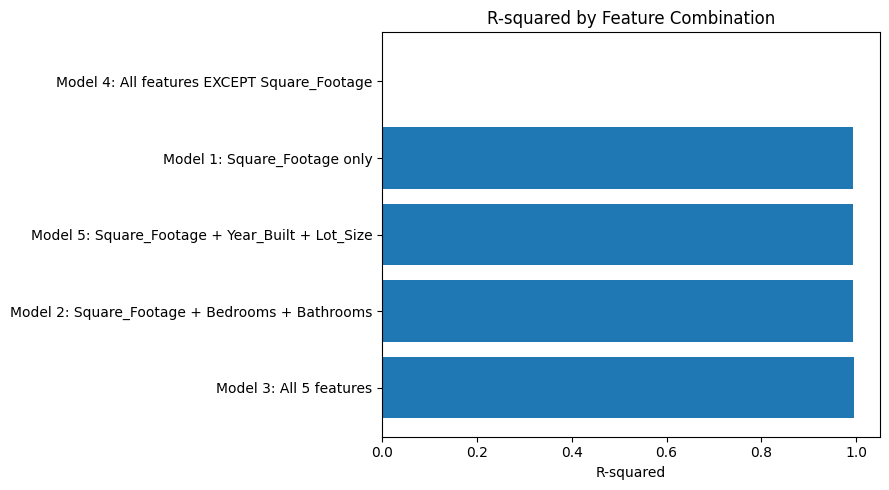

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.barh(results_df["Model"], results_df["R2"])
plt.xlabel("R-squared")
plt.title("R-squared by Feature Combination")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig("r2_comparison_pyspark.png", dpi=150)
plt.show()


In [13]:
spark.stop()


## Deliverable 3: Reflective Summary

### Feature selection choices

I selected five feature combinations deliberately rather than arbitrarily, in order to test a hypothesis rather than
just report numbers. Before modelling, I checked each candidate feature's raw correlation with `Price` and found
`Square_Footage` correlates at approximately 0.996, while `Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, and `Lot_Size`
each correlate below 0.04. This shaped my model design: alongside the "obvious" combinations (all features, a few
intuitive features together), I deliberately included **Model 1 (Square_Footage alone)** and **Model 4 (everything
except Square_Footage)** as a controlled comparison — isolating the one dominant predictor from the rest.

### Observations from model comparisons

- Any model that includes `Square_Footage` achieves R-squared above 0.99, regardless of which other features join it.
- Model 4, which excludes `Square_Footage` entirely, collapses to an R-squared near 0 (~0.002) — the four remaining
  features together explain almost none of the variance in `Price`.
- Adding more features beyond `Square_Footage` (Models 2, 3, 5) produces only marginal R-squared improvements (roughly
  +0.001 to +0.002) over Model 1 alone, with correspondingly small RMSE reductions.
- This indicates the dataset's price-generating relationship is overwhelmingly driven by square footage, with the
  other four features contributing negligible independent predictive signal on the full 1,000,000-row dataset.

### Challenges faced and how I resolved them

The main challenge was interpreting an unusually clean, strongly linear relationship — with real housing data I would
expect several features to matter and possible multicollinearity between them. Here that wasn't the case. I resolved
this by checking correlations before committing to feature sets, and by building the "everything except
Square_Footage" model specifically to confirm the other features' weak contribution wasn't an artefact of my
train/test split or feature selection — the R-squared collapsing to near-zero in Model 4 confirmed the effect is real.
A separate practical challenge was working with PySpark instead of a single-machine library: the property dataset is
large enough (1,000,000 rows) that a distributed pipeline (`VectorAssembler`, `StandardScaler`, and Spark's own
`LinearRegression`) is the appropriate tool, following the pattern of the Diabetes big-data example rather than a
smaller-scale library.

### Insights gained

The main lesson: R-squared comparison across feature sets is far more informative than fitting a single "kitchen
sink" model with every available feature. Running a deliberate ablation (removing the dominant feature to see what's
left) revealed something a single all-features model would have hidden — that four of the five available features
were contributing almost nothing. This reinforces the value of checking feature-target correlations before modelling,
and of designing model comparisons that test a specific question rather than just varying combinations at random.
